In [1]:
import pandas as pd
import numpy as np 
import sklearn
import networkx as nx
import matplotlib.pyplot as plt 
import seaborn as sns
from loguru import logger

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE 
import scipy.stats as stats
from sklearn.cluster import KMeans

import ast

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

# Preprocessing + Feature Engineering
## Graph Based Features

In [2]:
import numpy as np
import networkx as nx
from scipy import stats

def centralities(edgelist):
    """
    Compute an extended set of structural features for each node in the graph.

    Parameters:
        edgelist: List of tuples representing undirected edges [(u, v), ...]

    Returns:
        Tuple:
          - Dictionary mapping node -> tuple of structural, centrality, and entropy features
          - List of feature names corresponding to the tuple order
    """
    T = nx.from_edgelist(edgelist)

    degree = dict(T.degree())
    degree_squared = {v: deg ** 2 for v, deg in degree.items()}

    degree_diff = {
        v: np.mean([degree[v] - degree[nbr] for nbr in T.neighbors(v)]) 
        if len(list(T.neighbors(v))) > 0 else 0.0
        for v in T.nodes()
    }

    local_degree_ratio = {
        v: degree[v] / (np.mean([degree[nbr] for nbr in T.neighbors(v)]) + 1e-5)
        if len(list(T.neighbors(v))) > 0 else 0.0
        for v in T.nodes()
    }

    max_neighbor_degree = {
        v: max([degree[nbr] for nbr in T.neighbors(v)], default=0)
        for v in T.nodes()
    }

    avg_neighbor_deg = nx.average_neighbor_degree(T)
    clustering = nx.clustering(T)

    dc = nx.degree_centrality(T)
    cc = nx.harmonic_centrality(T)
    bc = nx.betweenness_centrality(T)
    pc = nx.pagerank(T)

    degrees = np.array(list(degree.values()))
    p_deg = degrees / degrees.sum()
    global_entropy = stats.entropy(p_deg)

    local_entropy = {
        v: stats.entropy(
            np.array([degree[nbr] for nbr in T.neighbors(v)]) /
            (sum([degree[nbr] for nbr in T.neighbors(v)]) + 1e-5)
        ) if len(list(T.neighbors(v))) > 0 else 0.0
        for v in T.nodes()
    }

    is_leaf = {v: int(degree[v] == 1) for v in T.nodes()}
    threshold = np.percentile(list(degree.values()), 80)
    is_hub = {v: int(degree[v] >= threshold) for v in T.nodes()}

    # New features
    eccentricity = nx.eccentricity(T)
    closeness = nx.closeness_centrality(T)
    triangles = nx.triangles(T)
    kcore = nx.core_number(T)
    avg_sp_length = {
        v: np.mean(list(nx.single_source_shortest_path_length(T, v).values()))
        for v in T.nodes()
    }

    feature_names = [
        "degree",
        "degree_squared",
        "degree_diff",
        "local_degree_ratio",
        "max_neighbor_degree",
        "avg_neighbor_deg",
        "clustering",
        "degree_centrality",
        "harmonic_centrality",
        "betweenness_centrality",
        "pagerank",
        "is_leaf",
        "is_hub",
        "local_entropy",
        "global_entropy",
        "eccentricity",
        "closeness_centrality",
        "triangle_count",
        "kcore_number",
        "avg_shortest_path_length"
    ]

    features = {
        v: (
            degree[v],
            degree_squared[v],
            degree_diff[v],
            local_degree_ratio[v],
            max_neighbor_degree[v],
            avg_neighbor_deg[v],
            clustering[v],
            dc[v],
            cc[v],
            bc[v],
            pc[v],
            is_leaf[v],
            is_hub[v],
            local_entropy[v],
            global_entropy,
            eccentricity[v],
            closeness[v],
            triangles[v],
            kcore[v],
            avg_sp_length[v]
        )
        for v in T.nodes()
    }

    return features, feature_names

# Ready to use
centralities


<function __main__.centralities(edgelist)>

## Preprocessing pipeline 
Graph + PCA + Standardization

In [5]:
from loguru import logger
import pandas as pd
import numpy as np
import networkx as nx
import ast

def create_dataset(
    df, 
    include_root=True, 
    normalize_by_length=False,
    scaler=None,           
    dim_reducer=None,      
    dim_reducer_name='dim_reduced'
):
    logger.info("Starting dataset creation...")
    logger.info(f"Total rows to process: {len(df)}")
    logger.info(f"Options - include_root: {include_root}, normalize_by_length: {normalize_by_length}")
    
    dataset = []
    metadata_cols = ['sentence_id', 'language', 'node', 'sentence_length']
    if include_root:
        metadata_cols.append('root')
    
    raw_features = []
    meta_data = []
    
    for i, row in df.iterrows():
        edges = ast.literal_eval(row['rand_edgelist'])
        features_dict, feature_names = centralities(edges)
        T = nx.from_edgelist(edges)
        length = len(T.nodes())

        for node, feats in features_dict.items():
            meta_row = [
                row['sentence'],
                row['language'],
                node,
                length
            ]
            if include_root:
                root = 1 if node == row['root'] else 0
                meta_row.append(root)
            
            feats = np.array(feats)
            if normalize_by_length:
                feats = feats / (length + 1e-5)
            
            meta_data.append(meta_row)
            raw_features.append(feats.tolist())
    
    # STEP 1: GRAPH BASED FEATURES
    meta_df = pd.DataFrame(meta_data, columns=metadata_cols)
    features_df = pd.DataFrame(raw_features, columns=feature_names)
    logger.info(f"Extracted {features_df.shape[1]} features per node for {len(features_df)} nodes.")

    # STEP 2: SCALING
    if scaler:
        features_scaled = scaler.fit_transform(features_df)
        logger.info(f"Features scaled using: {scaler.__class__.__name__}")
    else:
        features_scaled = features_df.values
        logger.info("No scaler applied to features.")

    # STEP 3: DIMENSIONALITY REDUCTION
    if dim_reducer:
        dim_reduced = dim_reducer.fit_transform(features_scaled)
        logger.info(f"Dimensionality reduction using: {dim_reducer.__class__.__name__}")
        logger.info(f"Output shape after reduction: {dim_reduced.shape}")

        if hasattr(dim_reducer, 'explained_variance_ratio_'):
            explained = dim_reducer.explained_variance_ratio_
            logger.info(f"Explained variance (PCA): {explained}")
            logger.info(f"Cumulative explained variance: {explained.cumsum()}")

        dim_reduced_df = pd.DataFrame(
            dim_reduced, 
            columns=[f"{dim_reducer_name}_{i+1}" for i in range(dim_reduced.shape[1])]
        )
        final_df = pd.concat([meta_df.reset_index(drop=True), 
                              pd.DataFrame(features_scaled, columns=feature_names).reset_index(drop=True),
                              dim_reduced_df.reset_index(drop=True)], axis=1)
    else:
        logger.info("No dimensionality reduction applied.")
        final_df = pd.concat([meta_df.reset_index(drop=True), 
                              pd.DataFrame(features_scaled, columns=feature_names).reset_index(drop=True)], axis=1)

    logger.success("Dataset creation completed!")
    return final_df


In [7]:
train = pd.read_csv('data/train-random.csv')
train_dataset = create_dataset(
    train, 
    include_root=True,
    normalize_by_length=True,
    scaler=StandardScaler(),
    dim_reducer=PCA(n_components=3),
    dim_reducer_name='pca'
)

train_dataset.to_csv('data/train_dataset_ultraprocessed.csv', index=False)


test = pd.read_csv('data/test-random.csv')
test_dataset = create_dataset(
    test, 
    include_root=False,
    normalize_by_length=True,
    scaler=StandardScaler(),
    dim_reducer=PCA(n_components=3),
    dim_reducer_name='pca'
)
test_dataset.to_csv('data/test_dataset_ultraprocessed.csv', index=False)


2025-05-29 13:38:05.056 | INFO     | __main__:create_dataset:15 - Starting dataset creation...
2025-05-29 13:38:05.056 | INFO     | __main__:create_dataset:16 - Total rows to process: 10500


2025-05-29 13:38:05.057 | INFO     | __main__:create_dataset:17 - Options - include_root: True, normalize_by_length: True
2025-05-29 13:39:09.111 | INFO     | __main__:create_dataset:54 - Extracted 20 features per node for 197479 nodes.
2025-05-29 13:39:09.143 | INFO     | __main__:create_dataset:59 - Features scaled using: StandardScaler
2025-05-29 13:39:09.162 | INFO     | __main__:create_dataset:67 - Dimensionality reduction using: PCA
2025-05-29 13:39:09.163 | INFO     | __main__:create_dataset:68 - Output shape after reduction: (197479, 3)
2025-05-29 13:39:09.163 | INFO     | __main__:create_dataset:72 - Explained variance (PCA): [0.52530136 0.27139031 0.10044183]
2025-05-29 13:39:09.164 | INFO     | __main__:create_dataset:73 - Cumulative explained variance: [0.52530136 0.79669167 0.8971335 ]
2025-05-29 13:39:09.183 | SUCCESS  | __main__:create_dataset:87 - Dataset creation completed!
2025-05-29 13:39:12.458 | INFO     | __main__:create_dataset:15 - Starting dataset creation...
2

## Exploratory Data Analysis

### Statistics

From just looking at the raw statistic we see that sentence length can vary greatly among graphs, some of them reaching 70. We also see that clustering and triangle measure has resulted finally useless for some reason, so we will remove it until we find what is the root cause of such behaviour. 

In [8]:
train_dataset.drop(columns=["clustering", "triangle_count"], inplace=True)
test_dataset.drop(columns=["clustering", "triangle_count"], inplace=True)
train_dataset.describe()


,sentence_id,node,sentence_length,root,degree,degree_squared,degree_diff,local_degree_ratio,max_neighbor_degree,avg_neighbor_deg,...,is_hub,local_entropy,global_entropy,eccentricity,closeness_centrality,kcore_number,avg_shortest_path_length,pca_1,pca_2,pca_3
count,197479.000000,197479.000000,197479.000000,197479.000000,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,...,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05,1.974790e+05
mean,499.636584,11.687076,22.374151,0.053170,1.537094e-16,3.346203e-17,-5.569808e-17,-4.972529e-17,4.491827e-16,-4.893372e-17,...,1.298902e-16,1.611215e-16,-2.273979e-16,9.336265e-16,-1.706923e-16,9.254229e-17,9.441329e-17,-4.375250e-17,4.749449e-17,-3.857128e-17
std,291.353683,8.269808,8.959233,0.224373,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,3.074975e+00,2.210215e+00,1.344605e+00
min,2.000000,1.000000,3.000000,0.000000,-1.223667e+00,-7.763849e-01,-6.942018e+00,-9.984416e-01,-1.547983e+00,-1.495018e+00,...,-6.679151e-01,-8.884095e-01,-2.121851e+00,-2.374534e+00,-9.487177e-01,-1.498031e+00,-2.372584e+00,-4.128420e+00,-8.636039e+00,-7.521832e+00
25%,238.000000,5.000000,16.000000,0.000000,-7.098417e-01,-6.413518e-01,-5.170712e-01,-6.327945e-01,-7.088410e-01,-6.853007e-01,...,-6.679151e-01,-8.884095e-01,-7.008319e-01,-7.353216e-01,-5.293156e-01,-6.215325e-01,-7.336217e-01,-1.964270e+00,-1.473597e+00,-9.030980e-01
50%,491.000000,10.000000,21.000000,0.000000,-2.782282e-01,-3.236269e-01,2.097879e-02,-2.954020e-01,-2.053561e-01,-2.364759e-01,...,-6.679151e-01,-1.079956e-01,-1.421745e-01,-1.253821e-01,-2.644902e-01,-2.138591e-01,-1.351722e-01,-8.115846e-01,-3.457000e-01,-2.506381e-02
75%,736.000000,16.000000,27.000000,0.000000,3.691914e-01,1.794372e-01,5.843493e-01,3.119038e-01,4.659575e-01,4.047027e-01,...,6.515041e-01,5.448916e-01,5.348289e-01,6.018517e-01,1.773525e-01,3.594316e-01,6.045422e-01,1.056264e+00,1.087762e+00,8.958017e-01
max,995.000000,70.000000,70.000000,1.000000,1.056005e+01,1.384600e+01,7.743576e+00,1.792369e+01,7.906339e+00,9.124719e+00,...,9.887407e+00,9.100871e+00,5.048485e+00,4.921866e+00,2.190074e+01,1.079329e+01,4.504399e+00,4.759899e+01,1.882095e+01,5.620794e+00


### Correlation

As we can see, degree variable is one of the most informative although correlated variable. Most of the centrality scores have a high positive correlation among each other or with the degree variable. For example page rank and degree centrality are perfectly positively correlated with each other.

Moreover, we can see that sentence length has a lot of negative correlations with several variables, most notably global entropy and kcore_number. This has probablt something to do with the sentence_length normalization we applied to this data.


Finally, we also see that PCA components have a vastly different variable importance. The first component is centered around degree and centrality measures, while the 2nd component has high direct correlation with is_leaf, avg_neighbor_degree, avg_shortest_path_length... it seems to be connected to the graph topology. The 3rd component is less explicative, although we see its closely related to eccentricity and average shortest path length.

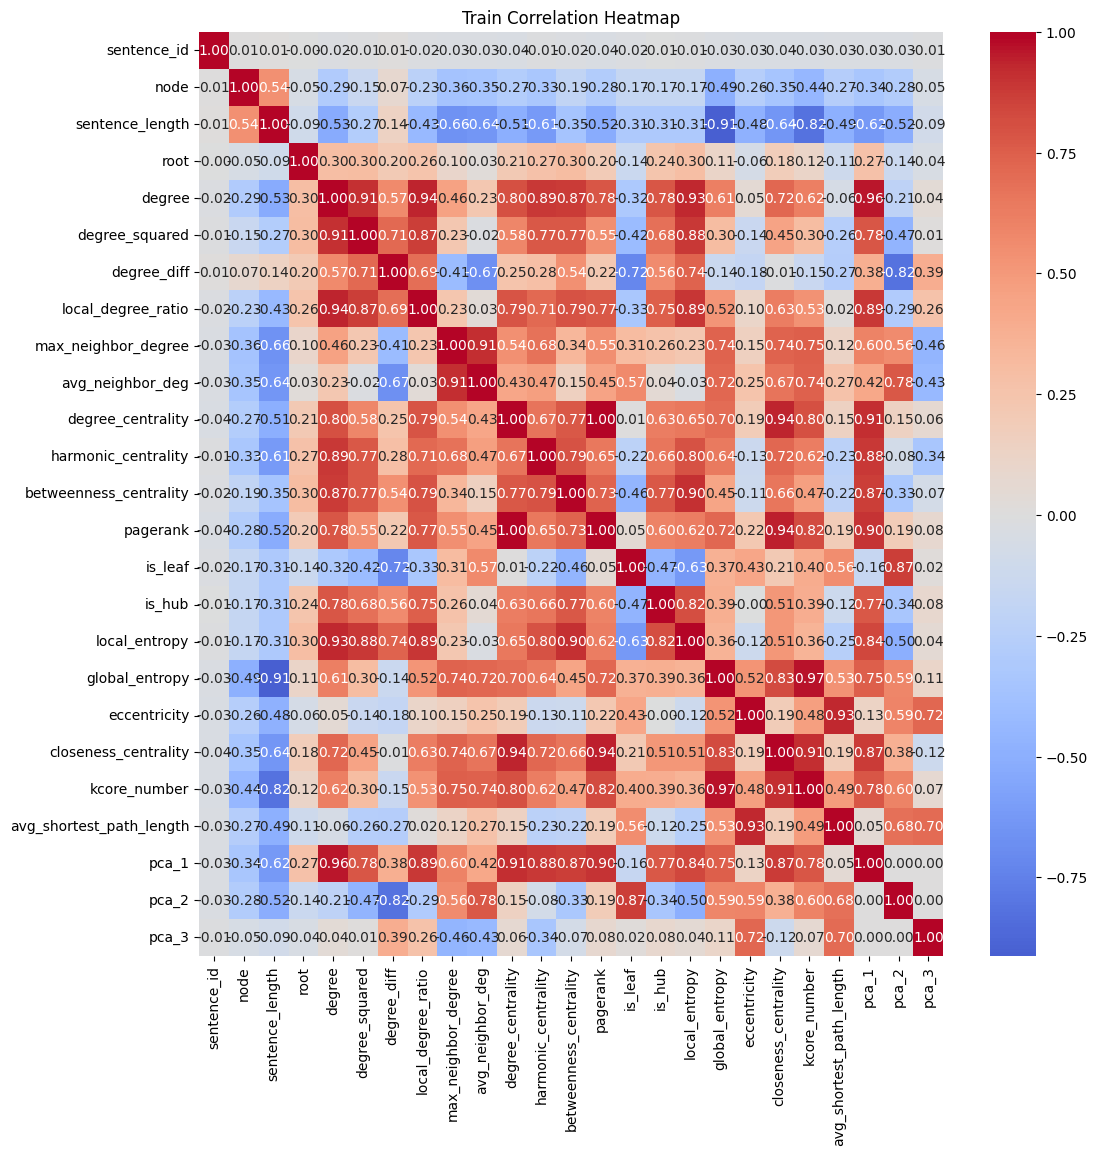

In [9]:
corr_matrix = train_dataset.corr(numeric_only=True)
plt.figure(figsize=(12,12))
sns.heatmap(data=corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Train Correlation Heatmap")
plt.show()

### Pairplots

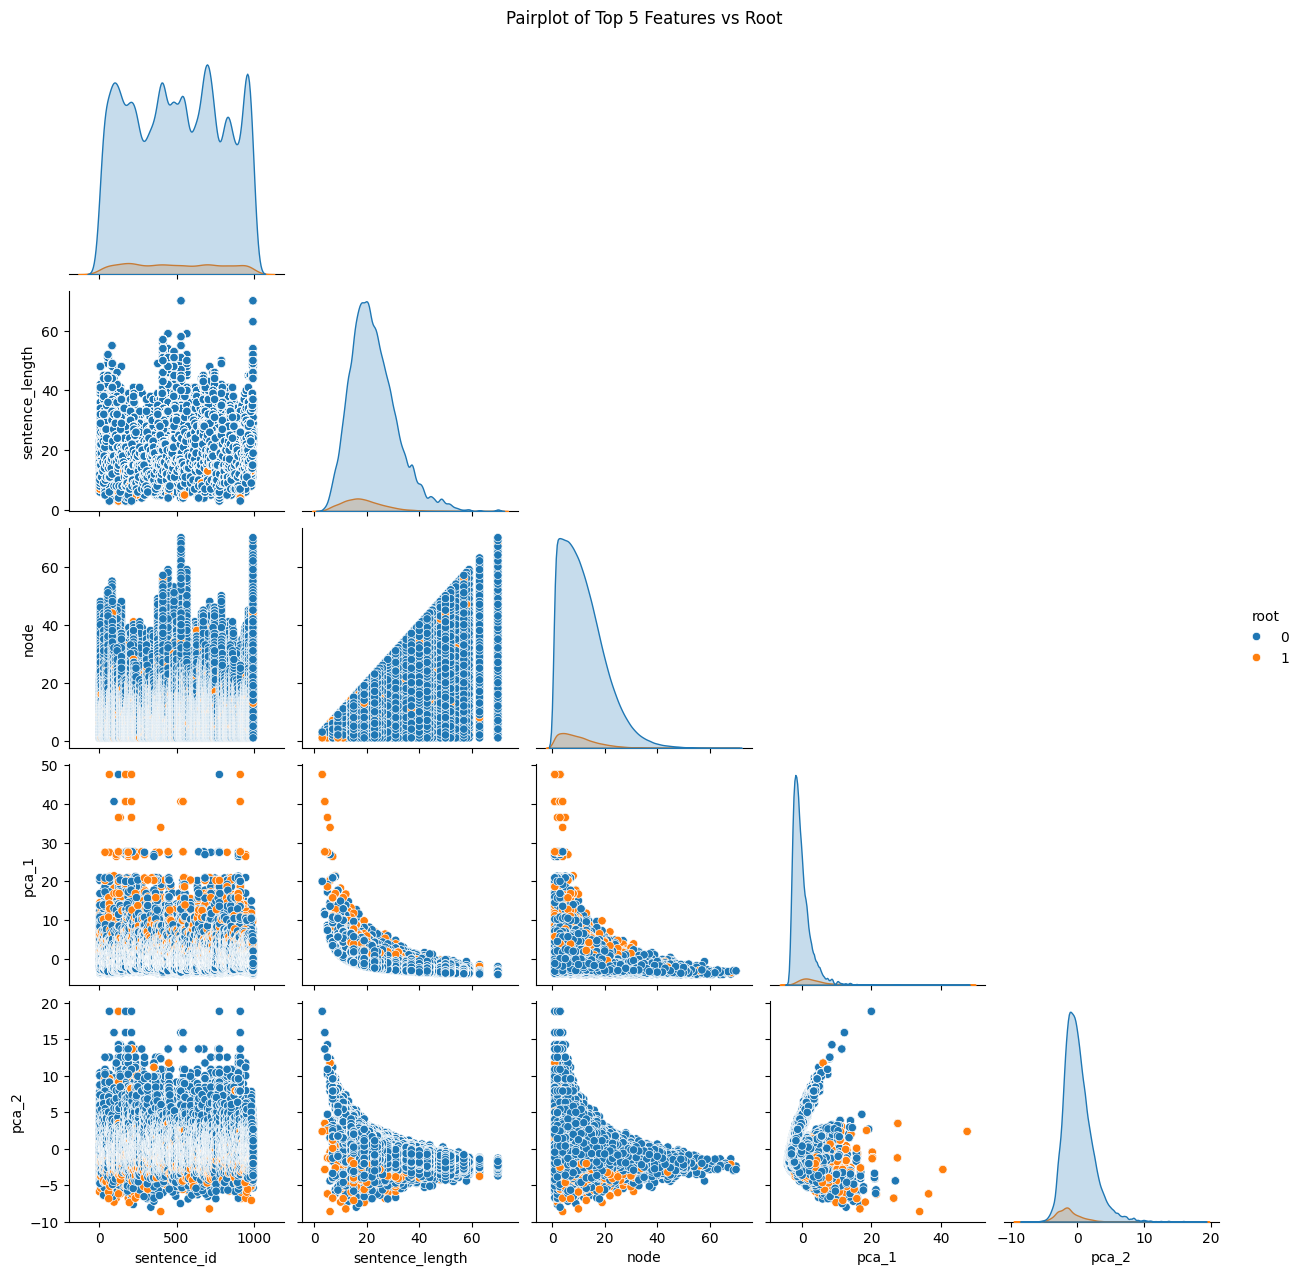

In [10]:
numeric_cols = train_dataset.select_dtypes(include='number').columns

top_vars = train_dataset[numeric_cols].std().sort_values(ascending=False).head(5).index
sns.pairplot(train_dataset[top_vars.tolist() + ['root']], hue='root', corner=True)
plt.suptitle("Pairplot of Top 5 Features vs Root", y=1.02)
plt.show()


### Variable Distribution

From the following numerical variables distributions we can gather several insights:
- Sentence length follows a quasi-gaussian distribution centered at 20
- Degree and centrality scores tend to follow exponential distributions
- Some variables such as max_neighbor_degree, avg_neighbor_degree, eccentricity, global_entropy and avg_shortest_path_length follow a gamma-like distribution

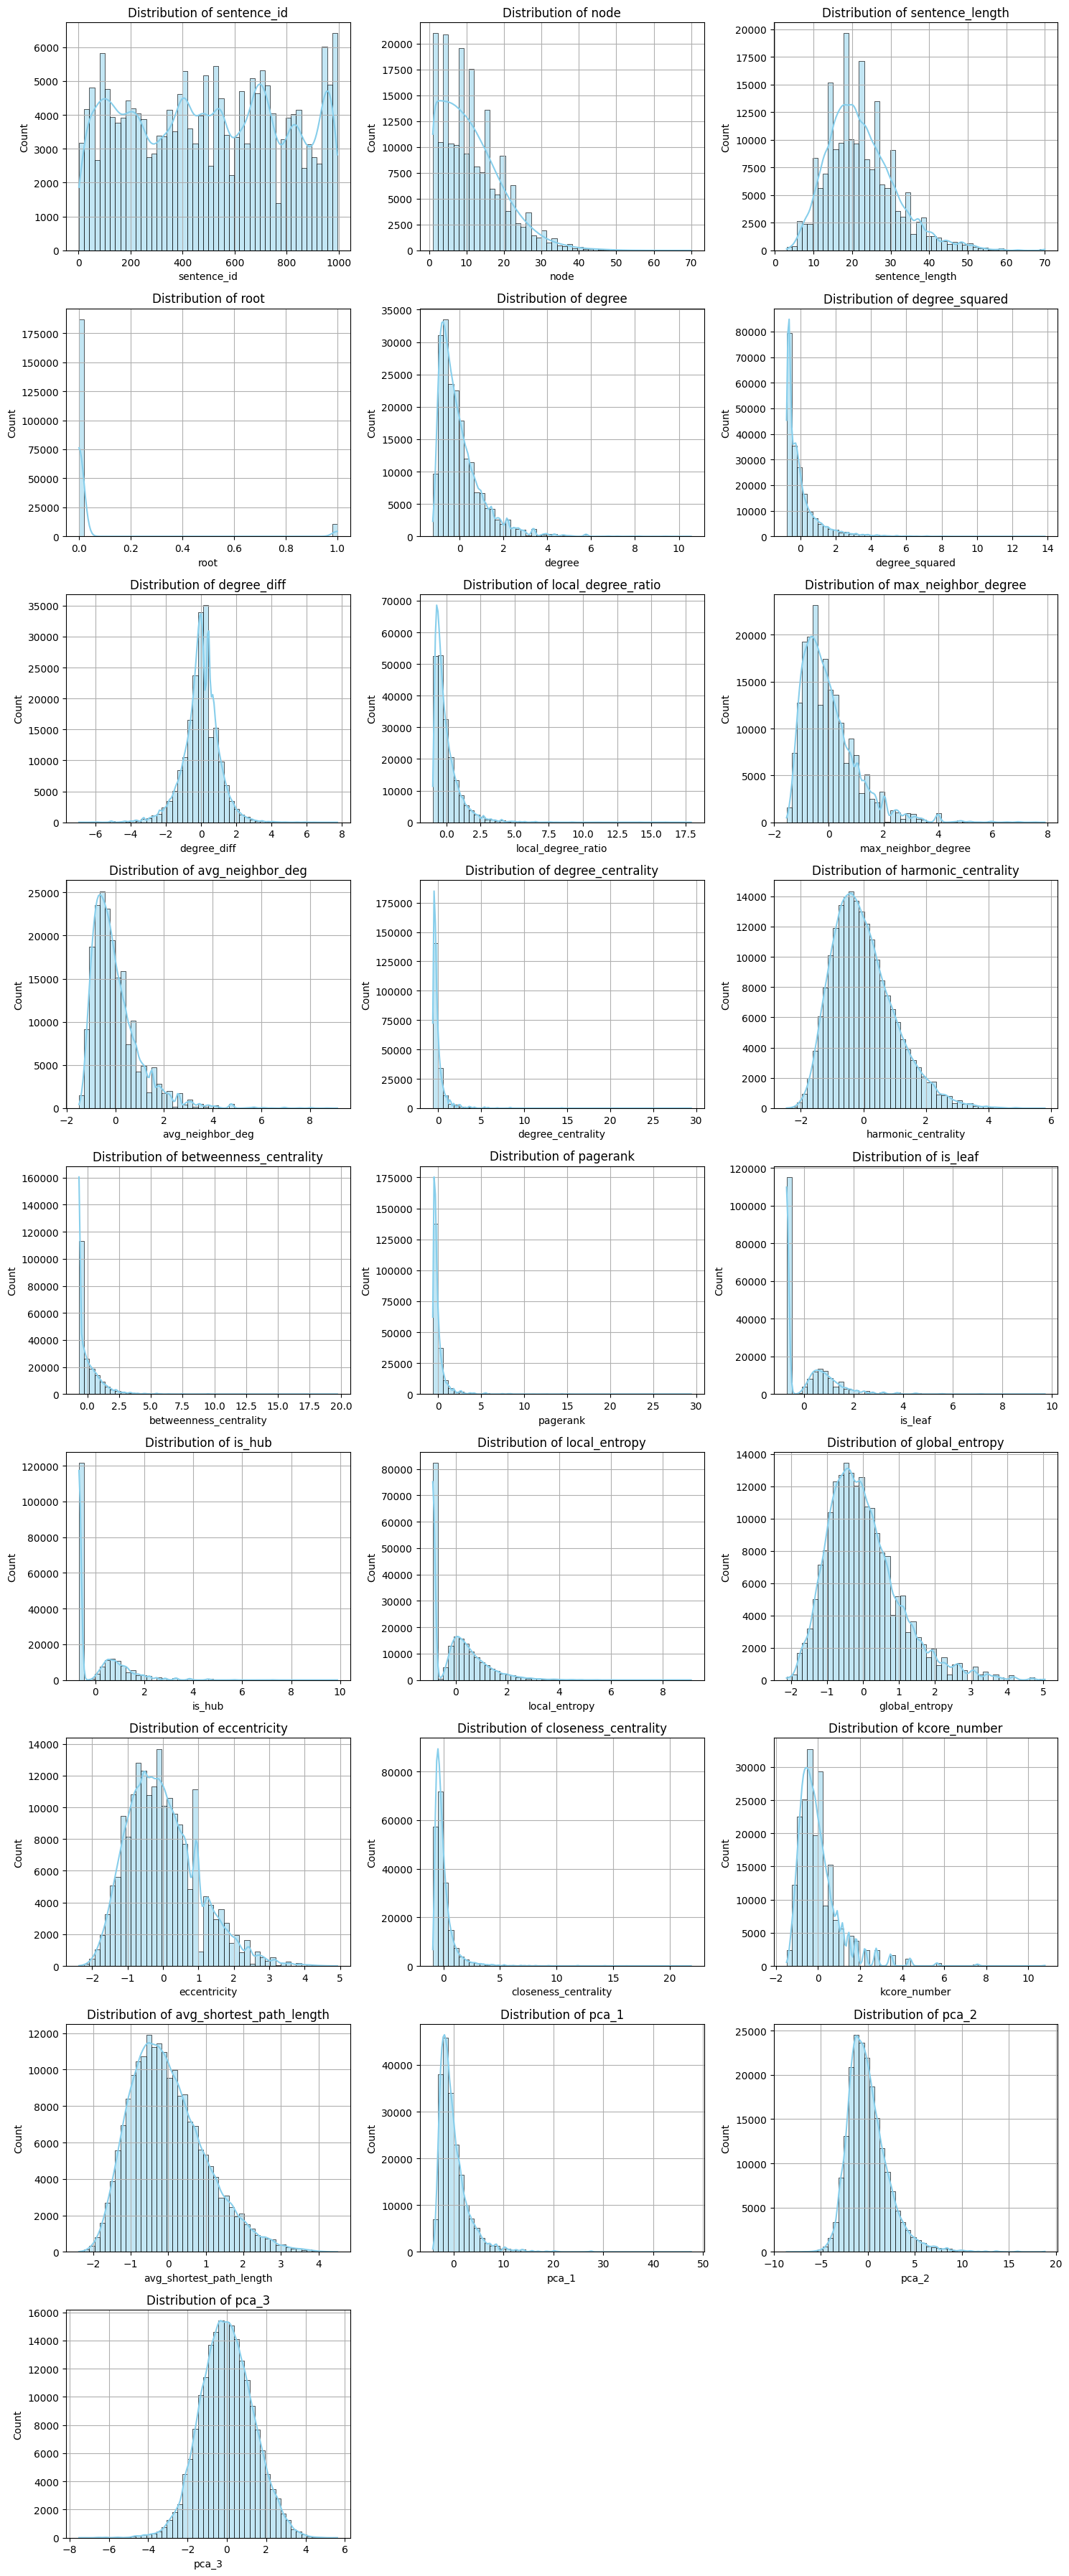

In [11]:
numeric_cols = train_dataset.select_dtypes(include='number').columns
n_cols = 3  # how many plots per row
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(train_dataset[col], kde=True, bins=50, color='skyblue', ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### PCA + KMeans Clustering

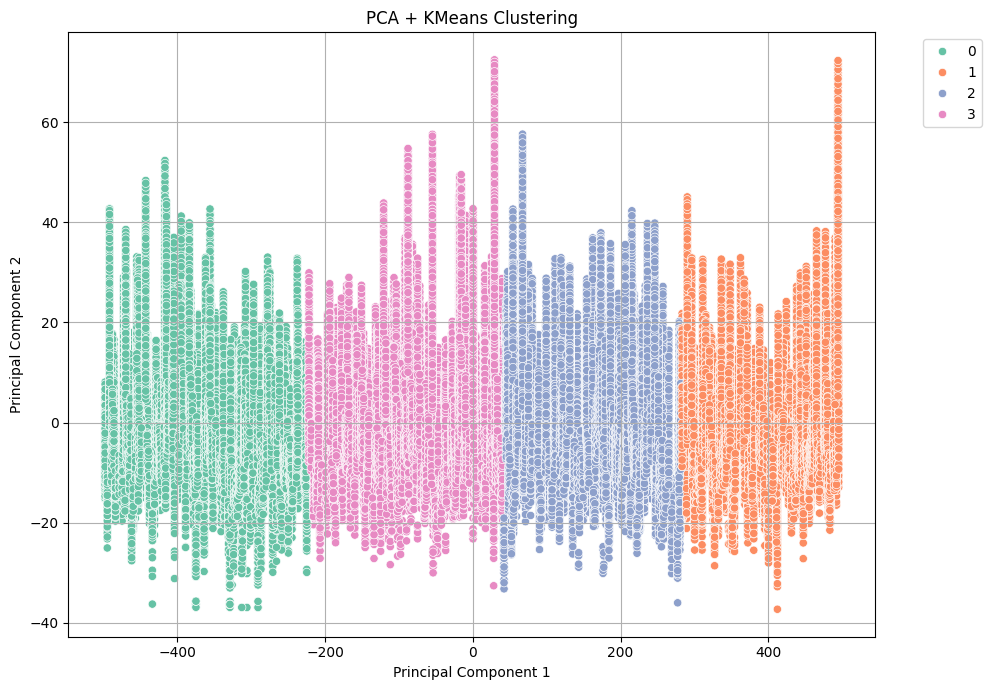

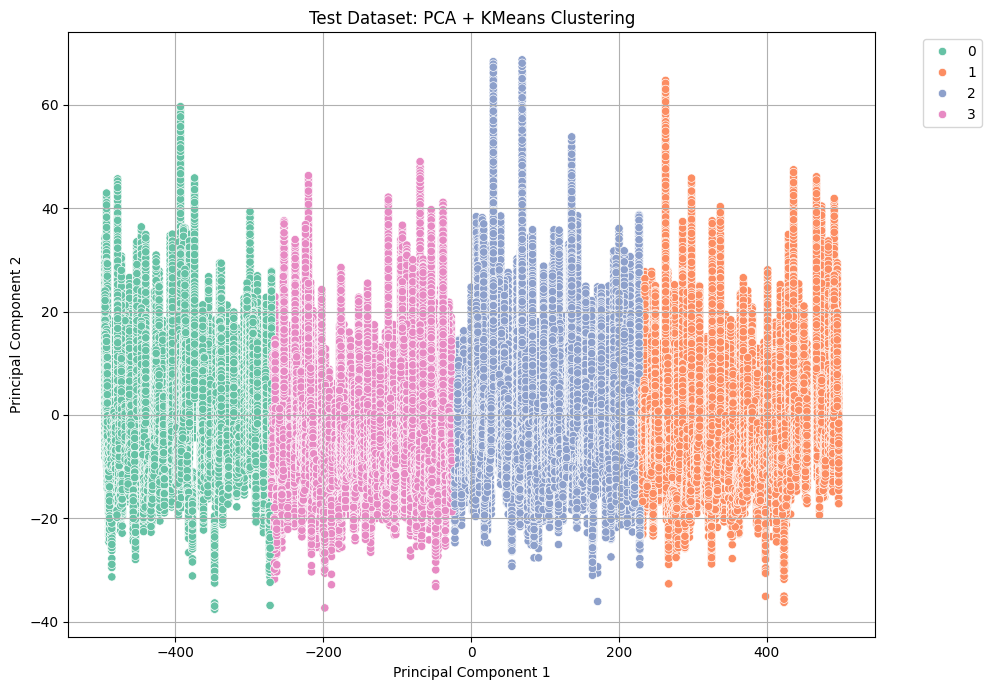

In [12]:
# Select only numeric variables
X = train_dataset.select_dtypes(include='number')
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)
train_dataset['cluster'] = labels

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=train_dataset['cluster'],        # Main clustering hue
    palette='Set2'
)

plt.title("PCA + KMeans Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # tidy legend
plt.grid(True)
plt.tight_layout()
plt.show()

# Select only numeric variables
X_test = test_dataset.select_dtypes(include='number')

# PCA
pca_test = PCA(n_components=2, random_state=42)
X_test_pca = pca_test.fit_transform(X_test)

# KMeans clustering
kmeans_test = KMeans(n_clusters=4, random_state=42)
test_labels = kmeans_test.fit_predict(X_test_pca)
test_dataset['cluster'] = test_labels

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_test_pca[:, 0],
    y=X_test_pca[:, 1],
    hue=test_dataset['cluster'],
    palette='Set2'
)
plt.title("Test Dataset: PCA + KMeans Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


### Profiling

In [13]:
numeric_summary = train_dataset.groupby('cluster').describe().T
display(numeric_summary)

cluster                       0             1             2             3
sentence_id count  55776.000000  42384.000000  47172.000000  52147.000000
            mean     136.283455    899.563892    662.786611    415.638503
            std       76.111670     64.681770     66.126374     74.604827
            min        2.000000    783.000000    542.000000    278.000000
            25%       76.000000    839.000000    611.000000    354.000000
...                         ...           ...           ...           ...
pca_3       min       -6.563179     -6.165818     -5.502473     -7.521832
            25%       -0.816569     -0.854888     -0.985560     -0.958803
            50%        0.078778      0.037023     -0.113907     -0.096434
            75%        0.989240      0.955728      0.793544      0.824881
            max        4.689863      4.899255      5.620794      4.949729

[200 rows x 4 columns]

In [14]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(train_dataset['language'], train_dataset['cluster'])
chi2, p, _, _ = chi2_contingency(contingency)

print("Chi-squared test:")
print(f"Chi2 statistic = {chi2:.2f}")
print(f"p-value = {p:.4f}")
display(contingency.style.background_gradient(cmap='Blues'))


Chi-squared test:
Chi2 statistic = 103.51
p-value = 0.0004


cluster,0,1,2,3
language,,,,
Arabic,2653,1960,2185,2445
Chinese,2655,2031,2161,2445
Czech,2230,1742,1952,2131
English,2576,2107,2227,2505
Finnish,1942,1431,1642,1771
French,3114,2382,2697,2997
Galician,2978,2262,2527,2850
German,2599,2018,2303,2462
Hindi,3140,2293,2621,2859


<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

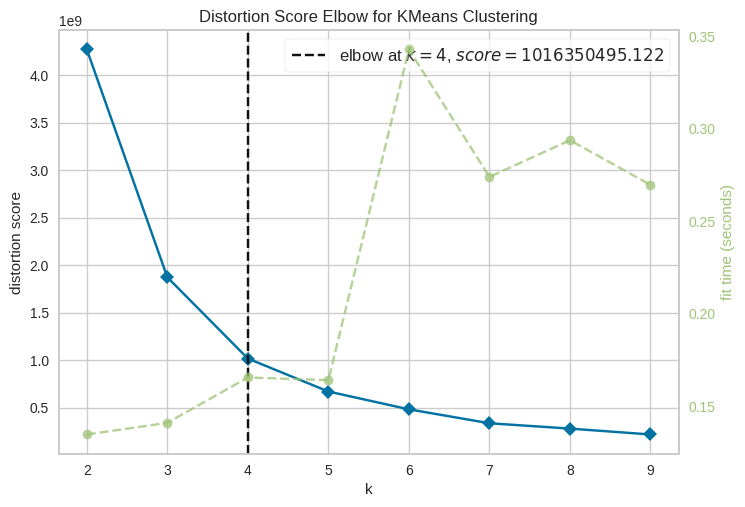

In [15]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,10))
visualizer.fit(X_pca)
visualizer.show(outpath="elbow_plot.png")       # Display the plot


In [16]:
test_dataset.describe()

,sentence_id,node,sentence_length,degree,degree_squared,degree_diff,local_degree_ratio,max_neighbor_degree,avg_neighbor_deg,degree_centrality,...,local_entropy,global_entropy,eccentricity,closeness_centrality,kcore_number,avg_shortest_path_length,pca_1,pca_2,pca_3,cluster
count,194648.000000,194648.000000,194648.000000,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,...,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,1.946480e+05,194648.000000
mean,495.764380,11.702607,22.405214,-2.476430e-16,8.527331e-17,2.219442e-17,-2.394661e-16,2.137673e-16,-1.460159e-16,-4.322072e-17,...,1.314143e-16,-2.546518e-16,1.401753e-17,7.943267e-17,-3.037131e-17,-6.541514e-17,-4.205259e-17,-2.102629e-17,1.022112e-18,1.515027
std,287.653836,8.291725,9.000504,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,3.080689e+00,2.214817e+00,1.340394e+00,1.083760
min,1.000000,1.000000,3.000000,-1.204116e+00,-7.696866e-01,-7.325087e+00,-9.854888e-01,-1.488464e+00,-1.467311e+00,-6.125800e-01,...,-8.858731e-01,-2.058056e+00,-2.477110e+00,-9.317066e-01,-1.452140e+00,-2.475703e+00,-4.055920e+00,-1.076339e+01,-8.117903e+00,0.000000
25%,258.000000,5.000000,16.000000,-7.059246e-01,-6.377272e-01,-4.830766e-01,-6.255390e-01,-6.880222e-01,-6.661321e-01,-4.412892e-01,...,-8.858731e-01,-7.310049e-01,-7.424912e-01,-5.374793e-01,-6.675915e-01,-7.387085e-01,-1.963027e+00,-1.478595e+00,-9.044554e-01,1.000000
50%,509.000000,10.000000,21.000000,-2.798122e-01,-3.219671e-01,3.285614e-02,-2.958907e-01,-1.989985e-01,-2.451204e-01,-2.808900e-01,...,-1.110671e-01,-1.553983e-01,-1.113944e-01,-2.770311e-01,-2.183203e-01,-1.336132e-01,-8.111185e-01,-3.590643e-01,-3.408139e-02,2.000000
75%,743.000000,16.000000,28.000000,3.593561e-01,1.779860e-01,5.731253e-01,2.974756e-01,4.530335e-01,3.863961e-01,7.000306e-02,...,5.339035e-01,5.491888e-01,6.066554e-01,1.721294e-01,3.432686e-01,6.123392e-01,1.028118e+00,1.047762e+00,8.801049e-01,2.000000
max,993.000000,67.000000,67.000000,1.075852e+01,1.717638e+01,8.111158e+00,1.803481e+01,7.951393e+00,9.107338e+00,2.903727e+01,...,9.009149e+00,4.951959e+00,4.648888e+00,2.139582e+01,1.056416e+01,4.257354e+00,4.694216e+01,1.820887e+01,5.069200e+00,3.000000


In [17]:
train_dataset.to_csv('data/train_dataset_ultraprocessed.csv', index=False)
test_dataset.to_csv('data/test_dataset_ultraprocessed.csv', index=False)